In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_wildlife_model():
    model = models.Sequential([
        # Layer 1: Detecting edges and textures
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
        layers.MaxPooling2D((2, 2)),

        # Layer 2: Detecting complex shapes (ears, eyes)
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # Layer 3: High-level features
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # Flattening to pass to the classifier
        layers.Flatten(),
        layers.Dense(128, activation='relu'),

        # Output: 3 classes (Cat, Dog, Bird)
        layers.Dense(3, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model = build_wildlife_model()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,739 (18.42 MB)

 Trainable params: 4,828,739 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

# 1. Load and prepare the CIFAR-10 dataset
# The dataset contains 60,000 color images in 10 classes
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# 2. Build the CNN Architecture
model = models.Sequential()

# Convolutional Layer: Applies filters to create feature maps
# Using 32 filters of size 3x3 with ReLU activation
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))

# Pooling Layer: Reduces spatial dimensions (MaxPooling)
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))

# 3. Add Dense Layers for Classification
model.add(layers.Flatten()) # Flattens the feature maps into a 1D vector
model.add(layers.Dense(64, activation='relu'))

# Output Layer: Softmax produces probabilities for each class
model.add(layers.Dense(10, activation='softmax'))

# 4. Compile the model
# Using Adam optimizer as suggested in reading
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

# 5. Train the model
history = model.fit(train_images, train_labels, epochs=10,
                    validation_data=(test_images, test_labels))

# 6. Evaluate and display results
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)
print(f'\nTest Accuracy: {test_acc}')

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 44s 27ms/step - accuracy: 0.3470 - loss: 1.7489 - val_accuracy: 0.5232 - val_loss: 1.3338
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - accuracy: 0.5635 - loss: 1.2260 - val_accuracy: 0.6265 - val_loss: 1.0616
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 40s 25ms/step - accuracy: 0.6326 - loss: 1.0505 - val_accuracy: 0.6504 - val_loss: 0.9950
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 25ms/step - accuracy: 0.6724 - loss: 0.9351 - val_accuracy: 0.6577 - val_loss: 0.9861
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 40s 25ms/step - accuracy: 0.6979 - loss: 0.8635 - val_accuracy: 0.6901 - val_loss: 0.8884
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 40s 25ms/step - accuracy: 0.7225 - loss: 0.7927 - val_accuracy: 0.6920 - val_loss: 0.8948
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.7380 - loss: 0.7468 - val_accuracy: 0.7101 - val_loss: 0.8383
Epoch 8/10
1563/1563 ━━

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


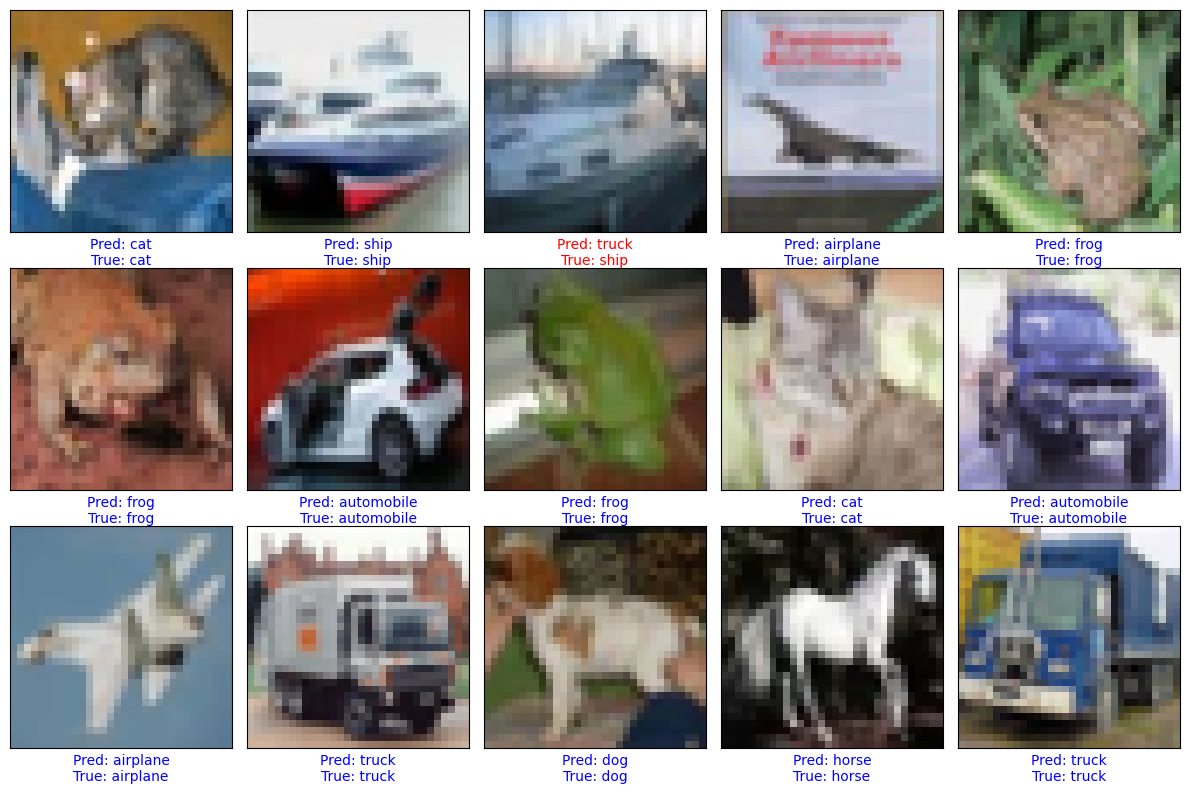

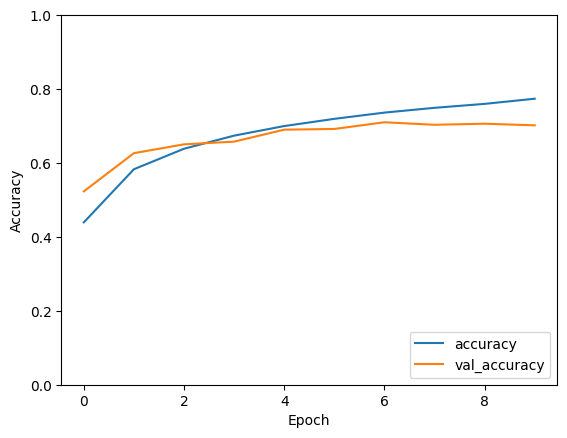

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 7. Visualize the first 15 predictions
predictions = model.predict(test_images)

plt.figure(figsize=(12, 8))
for i in range(15):
    plt.subplot(3, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(test_images[i])

    # Get the predicted label index
    predicted_label = np.argmax(predictions[i])
    true_label = test_labels[i][0]

    # Color code: Blue for correct, Red for incorrect
    color = 'blue' if predicted_label == true_label else 'red'

    plt.xlabel(f"Pred: {class_names[predicted_label]}\nTrue: {class_names[true_label]}",
               color=color)
plt.tight_layout()
plt.show()

# 8. Plot training history (Accuracy)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.show()